# PyTorch Lightning baseline template

by Andrés Muñoz-Jaramillo

This notebook is meant to act as a template to train and use a simple regression model to define a baseline that can be compared with a DS application.

It focuses on the concept of defining a PyTorch model, a PyTorch lightning training loop and the deffinition of metrics of performance.

This notebook assumes familiarity with the concepts of datasets and dataloaders contained in the **_0_dataset_dataloader_template.ipynb_**

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.   

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. It is what lets training.deterministic work without a
# cuBLAS warning on every run. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
from torch.utils.data import DataLoader

import torch
import yaml

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger, WandbLogger

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.

from workshop_infrastructure.utils import build_scalers  # Data scaling utilities for Surya stacks

torch.set_float32_matmul_precision('medium')



## Load configuration

Surya was designed to read a configuration file that defines many aspects of the model
including the data it uses we use this config file to set default values that do not
need to be modified, but also to define values specific to our downstream application

In [3]:
# The config is the single source of truth. load_flare_config() parses it into a typed
# object, exactly as the training script 3_finetune_template_1D.py does, so the same YAML
# behaves identically here and in production. Notebook 0 walks through what it contains.
from downstream_apps.template.configs import load_flare_config

cfg = load_flare_config("./configs/config_script_beastie.yaml")
print(f"Loaded config for job: {cfg.job_id}")



Loaded config for job: simsearch


## Download assets

The config says where the assets belong, so it is loaded first. `ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.


In [4]:
# One implementation, shared by the notebooks, the training script and the
# download_*.sh wrappers: workshop_infrastructure/assets.py.
# The linear baseline needs no backbone, so skip the 1.8 GB weights.
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers"])

# Now that scalers.yaml is guaranteed to be on disk, load it. build_scalers()
# accepts the resolved path directly.
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")


Loaded scalers for 13 channels.


## Define Downstream (DS) datasets

This child class takes as input all expected HelioFM parameters, plus additonal parameters relevant to the downstream application.  Here we focus in particular to the DS index and parameters necessary to combine it with the HelioFM index.

Another important component of creating a dataset class for your DS is normalization.  Here we use a log normalization on xray flux that will act as the output target.  Making log10(xray_flux) strictly positive and having 66% of its values between 0 and 1

In this case we will define both a training and a validation dataset using the indices pointed at in the config

**_Important:  In this notebook we sets max_number_of_samples=6 to potentially avoid going through the whole dataset as we explore it.  Keep in mind this for the future in case the database seems smaller than you expect_**


In [5]:
from downstream_apps.simsearch.datasets.simsearch_dataset import SimSearchSDataset
train_dataset = SimSearchSDataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=cfg.data.valid_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="valid",          # "val" disables random channel masking and flips
    # How s3:// paths in the index are read: "download" (default) | "simplecache" | "stream".
    # "download" fetches each file into s3_cache_dir first — recommended for NetCDF.
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    #### Put your downstream (DS) specific parameters below this line
    ds_sim_index_path=cfg.data.flare_index_path,
)

In [6]:
data_loader = DataLoader(
                dataset=train_dataset,
                batch_size=1,
                num_workers=8
            )

In [11]:
batch = next(iter(data_loader))

In [12]:
batch['ts'].shape

torch.Size([1, 14, 2, 4096, 4096])

In [8]:
from workshop_infrastructure.models.helio_spectformer import HelioSpectFormer
try:
    config = yaml.safe_load(open('./configs/config_script_beastie.yaml', "r"))
    print("Configuration loaded successfully!")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Make sure config_script.yaml exists in your current directory")
    raise

# build_scalers accepts a file path directly
scalers = build_scalers(info=config["data"]["scalers_path"])
model = HelioSpectFormer(
        #### Surya 366M defaults — must match the pretrained checkpoint
        img_size=config["model"]["img_size"],
        patch_size=config["model"]["patch_size"],
        in_chans=config["model"]["in_channels"],
        embed_dim=config["model"]["embed_dim"],
        time_embedding=config["model"]["time_embedding"],
        depth=config["model"]["depth"],
        n_spectral_blocks=config["model"]["spectral_blocks"],
        num_heads=config["model"]["num_heads"],
        mlp_ratio=config["model"]["mlp_ratio"],
        drop_rate=config["model"]["drop_rate"],
        dtype=torch.float32,
        window_size=config["model"]["window_size"],
        dp_rank=config["model"]["dp_rank"],
        learned_flow=config["model"]["learned_flow"],
        use_latitude_in_learned_flow=config["training"]["use_latitude_in_learned_flow"],
        init_weights=config["model"]["init_weights"],
        checkpoint_layers=config["model"]["checkpoint_layers"],
        rpe=config["model"]["rpe"],
        ensemble=config["model"]["ensemble"],
        nglo=config["model"]["nglo"],
        finetune=False,
    )

/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Configuration loaded successfully!


In [18]:
from downstream_apps.simsearch.models.simsearch_baseline import SimSuryaModel

In [19]:
baselineModel = SimSuryaModel(model)

In [20]:
x, x_ = baselineModel(batch)

In [13]:
baselineModel_ = SimSuryaModel(model, bbox=True)
x1, x1_ = baselineModel_(batch)

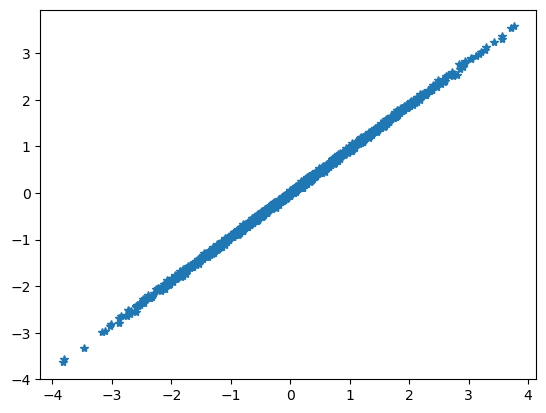

In [15]:
import matplotlib.pyplot as plt
plt.plot(x.detach().cpu().numpy()[0,:],x1.detach().cpu().numpy()[0,:], '*')

Training and validation get separate datasets and dataloaders. They differ only in the index they read and in `phase`: `phase="val"` turns off the random channel masking and vertical flips used for training augmentation.

The loaders use `multiprocessing_context="spawn"` — the dataset holds an S3 client that does not survive `fork`, and spawn also avoids lockups in shared environments.


In [21]:
# Inspect a single batch to confirm shapes before training.
train_data_loader = DataLoader(
                dataset=train_dataset,
                batch_size=2,
                num_workers=8
            )
batch = next(iter(train_data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})


Traceback (most recent call last):
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/shutil.py", line 759, in rmtree
    _rmtree_safe_fd(stack, onexc)
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/shutil.py", line 703, in _rmtree_safe_fd
    onexc(func, path, err)
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/shutil.py", line 750, in onexc
    return onerror(func, path, exc_info)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12

{'ts': (2, 14, 2, 4096, 4096), 'ts_aug': (2, 14, 2, 4096, 4096), 'bbox': 'list', 'bbox_aug': 'list', 'time_delta_input': (2, 2), 'key': 'list'}


## Define simple baseline model

Defining a simple baseline is important to understand what value is bringing the AI model to the problem.  

It is always very good to have a very simple baseline model.  Ideally one that cannot overfit the data.  This is a very good way of really measuring the value added of complex models.   Classical machine learning excels here:

- Regressions and logistic regressions.
- Climatological averages.
- Persistance.
- Simple transformations.

Simple models avoid excesively optimistic assessments of the capatiblities of a complex models and for many problems are actually remarkably hard to beat.

In this example we define a simple regression acting on the intensity of each channel.  Note that we invert the normalization to deal with strictly positive quantities.  As with the dataset we will be importing the model from a module so that we can use it within training scripts later on.

In [ ]:
from downstream_apps.simsearch.models.simsearch_baseline import SimSuryaModel

We can now test that this model manipulates a batch as expected and returns an estimate of flare intensity

Note that the simple regression model definition requires knowing the number of channels and timesteps so here we pull that information from the configuration intializing the model.

In [9]:
basemodel = HelioSpectFormer(
        #### Surya 366M defaults — must match the pretrained checkpoint
        img_size=config["model"]["img_size"],
        patch_size=config["model"]["patch_size"],
        in_chans=config["model"]["in_channels"],
        embed_dim=config["model"]["embed_dim"],
        time_embedding=config["model"]["time_embedding"],
        depth=config["model"]["depth"],
        n_spectral_blocks=config["model"]["spectral_blocks"],
        num_heads=config["model"]["num_heads"],
        mlp_ratio=config["model"]["mlp_ratio"],
        drop_rate=config["model"]["drop_rate"],
        dtype=torch.float32,
        window_size=config["model"]["window_size"],
        dp_rank=config["model"]["dp_rank"],
        learned_flow=config["model"]["learned_flow"],
        use_latitude_in_learned_flow=config["training"]["use_latitude_in_learned_flow"],
        init_weights=config["model"]["init_weights"],
        checkpoint_layers=config["model"]["checkpoint_layers"],
        rpe=config["model"]["rpe"],
        ensemble=config["model"]["ensemble"],
        nglo=config["model"]["nglo"],
        finetune=False,
    )
model = SimSuryaModel(basemodel)


Now we can pass the input stack 'ts' to the model to transform it into our regression output.   Note that since this model has not been trained and was initalized randomly.  The output here has no real meaning.  It only acts as a test that our model forward doesn't have dimension problems.

Dimension problemns are the dominant source of error in this kind of work.

Note that our output has now the size of our batch.

In [24]:
output, output_ = model.forward(batch)  # Get rid of singleton dimension

## Define your metrics

Metrics are a very important part of training AI models.   They provide your models with the quantitification of error, which in turn shifts the weights towards better pefrorming models.  They also provide a way for you to monitor performance, identify overfitting, and quantify value added. 

We now initialize the metrics class which allows you to control what metrics do you want to use as "loss" (i.e. the metrics that backpropagate through your model) and which ones for monitoring performance.  As with other components, this takes the form of a loaded module that can be later use in a training script

In [ ]:
from downstream_apps.simsearch.metrics.simsearch_metrics import SimsearchMetrics

In [15]:
train_loss_metrics = SimsearchMetrics("train_loss")

Now they can be evaluated in our model's output and our ground truth.   First the loss that actually will backpropagate, in this case Mean Squared Errror

In [27]:
train_loss_metrics(output, output_)

({'cosine': tensor(-0.9983)}, [1])

Then a training evaluation that will not backpropagate and inform our model, but that we can keep an eye on. Note that reporting lots of metrics during training will slow the training process.  I'm including it her as an example, but oftentimes is better to put the diagnostics only in the validation evaluation metrics.

Here we are caclulating the Root Relative Squared Error https://lightning.ai/docs/torchmetrics/stable/regression/rse.html 

A value below one means the prediction is better than predicting the average.  It is unlikely that this metric will be lower than one with a randomly initialized model

In the validation evaluation metrics we report both MSE and RRSE

## Define your PyTorch ligthning module

In this workshop we will use PyTorch lightning to train our models.  PyTorch lighting reduces the amount of code required to implement a training loop in comparison to PyTorch (at the expense of control and versatility).  

Opening the FlareLightningModule shows a simple Lightning model implementation.  It consists of:

- An initialization of the class (metrics, model, and learning rate).
- The forward code that runs evaluation of the model.
- Training and validation steps.
- Configuration of optimizers.

In [10]:
from downstream_apps.simsearch.lightning_modules.pl_simsearch_baseline import SimsearchLightningModule

## Set your global seeds

Since training AI models generally uses stochastic gradient descent, it is a good idea to fix your random seeds so that your training exercise is reproducible.    

In [11]:
L.seed_everything(42, workers=True)

Seed set to 42


42

## Intialize Lightning module

Now we properly initalize the Lightning module to enable training, including passing the dictionary of metrics

In [16]:
metrics = {'train_loss': train_loss_metrics}

lit_model = SimsearchLightningModule(model, metrics, 
                                     lr=cfg.learning_rate,
                                     batch_size=2)


## Logging

In order to properly compare experiments against each other, it is very useful to log evaluation metrics in a place where they can be compared against other training runs.  In this workshop we will use Weights and Biases (WandB). 

The first time you run WandB in a machine it will ask you to login to WandB.  You should have received an invitation to our project.  In order to login you must:

- Select option 2 (existing account).   In VScode the dialog opens a box at the top of your screen.
- Click on get API Key (this will open a browser).
- Generate API Key.
- Paste it in the dialog box at the top of your VSCode

In [ ]:
project_name = cfg.wandb_project
run_name = "baseline_simsearch"  # give your run a descriptive name

wandb_logger = WandbLogger(
    entity=cfg.wandb_entity,  # set wandb_entity in the config; null = personal account
    project=project_name,
    name=run_name,
    log_model=False,
    save_dir="./wandb/wandb_tmp",
)

csv_logger = CSVLogger("runs", name=project_name)


## Initialize trainer

With the loggers done, now the trainer needs to be defined.  The trainer defines several properties of your training run. Here we define:

- The max number of epochs (one epoch represents your model seeing your entire training dataset).
- Define where the training run will take place (auto uses the GPU if possible, if not, CPU).
- The loggers.
- The callbacks (here we save the model with the lowest validation loss).
- Logging frequency (because we are working with a small dataset it needs to be small).

In [18]:
max_epochs = 2

# -------------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------------
trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    logger=[wandb_logger, csv_logger],
    log_every_n_steps=2,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

Finally we fit the model.  We pass the Lighting module, and our dataloaders.

In [20]:
train_data_loader = DataLoader(
                dataset=train_dataset,
                batch_size=2,
                num_workers=8
            )
trainer.fit(lit_model, train_data_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: Currently logged in as: sc8473 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name  | Type          | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model | SimSuryaModel | 366 M  | train | 0    
--------------------------------------------------------
366 M     Trainable params
0         Non-trainable params
366 M     Total params
1,464.760 Total estimated model params size (MB)
169       Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/d0/subhamoy/.conda/envs/surya_ws/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3783: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f959569b800>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f95956a7530, execution_count=20 error_before_exec=None error_in_exec=1 info=<ExecutionInfo object at 7f95956a7d10, raw_cell="train_data_loader = DataLoader(
                da.." transformed_cell="train_data_loader = DataLoader(
                da.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bbeastie/home/subhamoy/surya_workshop2026/surya_workshop/downstream_apps/simsearch/1_baseline_template.ipynb#Y100sdnNjb2RlLXJlbW90ZQ%3D%3D cell_meta=None> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Conclusion

With this we have now integrated our dataset, dataloaders, metrics, and baseline into an end-2-end training loop.  The next step is to substitute the simple model with Surya.